In [1]:
from typing import cast

from datasets import Dataset
from datasets import load_dataset as hf_load

cppe5_train = cast(Dataset, hf_load("rishitdagli/cppe-5", split="train"))

/home/aweng/2033/dataeval-flow/.nox/docs/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

# Save to disk in HuggingFace arrow format
data_path = Path("./data/cppe5/train")
cppe5_train.save_to_disk(str(data_path))

Saving the dataset (0/1 shards):   0%|                                                                                                                                     | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1876.69 examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1876.69 examples/s]

Saving the dataset (1/1 shards): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1801.71 examples/s]

In [3]:
from dataeval.config import set_max_processes

from dataeval_flow.config import (
    BoVWExtractorConfig,
    DataCleaningTaskConfig,
    DataCleaningWorkflowConfig,
    HuggingFaceDatasetConfig,
    PipelineConfig,
    SelectionConfig,
    SelectionStep,
    SourceConfig,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.cleaning.params import DataCleaningHealthThresholds

set_max_processes(8)  # Set max processes for parallel execution (adjust as needed)

advisory_workflow = DataCleaningWorkflowConfig(
    name="cppe5_advisory_clean",
    mode="advisory",
    outlier_method="adaptive",  # Use adaptive thresholding for outliers
    outlier_threshold=3.5,
    outlier_flags=["dimension", "pixel", "visual"],  # All image stat groups
    outlier_cluster_threshold=3.5,  # Cluster-based detection in embedding space (requires extractor).
    outlier_cluster_algorithm="hdbscan",
    outlier_n_clusters=5,  # CPPE-5 has 5 classes
    duplicate_cluster_sensitivity=0.5,  # Duplicate detection — hash-based plus cluster-based.
    duplicate_cluster_algorithm="hdbscan",
    duplicate_n_clusters=5,
    health_thresholds=DataCleaningHealthThresholds(
        exact_duplicates=0.0,  # No exact duplicates allowed (default)
        near_duplicates=5.0,  # Up to 5% near duplicates before warning (default)
        image_outliers=5.0,  # Relaxed from 3% default — CPPE-5 has diverse images
        target_outliers=10.0,  # Relaxed from 3% default — object detection has annotation variance
        classwise_outliers=12.0,  # Relaxed from 3% default — some classes are visually diverse
        class_label_imbalance=5.0,  # CPPE-5 has moderate imbalance (default)
    ),
)

task = DataCleaningTaskConfig(
    name="cppe5_clean",
    workflow="cppe5_advisory_clean",
    sources="cppe5_src",
    extractor="bovw_ext",
)

# Build the full pipeline config — datasets, sources, extractors, selections, workflows, and tasks
config = PipelineConfig(
    datasets=[
        HuggingFaceDatasetConfig(name="cppe5_train", path=str(data_path)),
    ],
    selections=[
        SelectionConfig(name="first500", steps=[SelectionStep(type="Limit", params={"size": 500})]),
    ],
    sources=[
        SourceConfig(name="cppe5_src", dataset="cppe5_train", selection="first500"),
    ],
    extractors=[
        BoVWExtractorConfig(name="bovw_ext", vocab_size=512, batch_size=32),
    ],
    workflows=[advisory_workflow],
    tasks=[task],
)

In [4]:
result = run_task(task, config, cache_dir=Path("./cache"))

In [5]:
print(result.report())


  DATA CLEANING COMPLETE. DATASET: 500 ITEMS. MODE: ADVISORY.
  Timestamp:    2026-06-09T17:45:18.028690+00:00
  Duration:     12.14s
  Source:       cppe5_src (cppe5_train[first500])
  Model:        bovw_ext (bovw)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Outliers ..................................... 59 images (11.8%)  [!!]
  Target Outliers .................................. 278 targets (12.8%)  [!!]
  Classwise Outliers ... worst: Coverall (18.3%), 2/5 classes over 12.0%  [!!]
  Duplicates ............................ 2 exact (0.4%), 30 near (6.0%)  [!!]
  Label Distribution ............. 5 classes, 500 items, imbalance 3.4:1  [..]

  Health: 4 warning(s) [!!] — review flagged findings

  IMAGE OUTLIERS                                               59 images (11.8%)
  59 images (11.8%) flagged as outliers.

  Metric     Count
  ---------  -----
  channels      19
  zeros         18
  size          18
  height    

In [6]:
assert result.dataset is not None
ds = result.dataset

In [7]:
raw = result.data.raw

# Collect unique outlier image indices, grouped by image
outlier_issues = raw.img_outliers["issues"]
outlier_grouped: dict[int, list[str]] = {
    idx: [i["metric_name"] for i in outlier_issues if i["item_index"] == idx]
    for idx in {i["item_index"] for i in outlier_issues}
}

outlier_indices = sorted(outlier_grouped)
print(f"Image outliers: {len(outlier_indices)} images flagged, {len(outlier_issues)} total flags")

Image outliers: 59 images flagged, 93 total flags


Outlier sample — flagged metrics per image:
  Image    16: channels
  Image    24: channels
  Image    28: zeros, channels
  Image    31: zeros, channels
  Image    35: channels
  Image    50: sharpness, channels
  Image    52: channels
  Image    60: zeros, channels
  Image    62: zeros


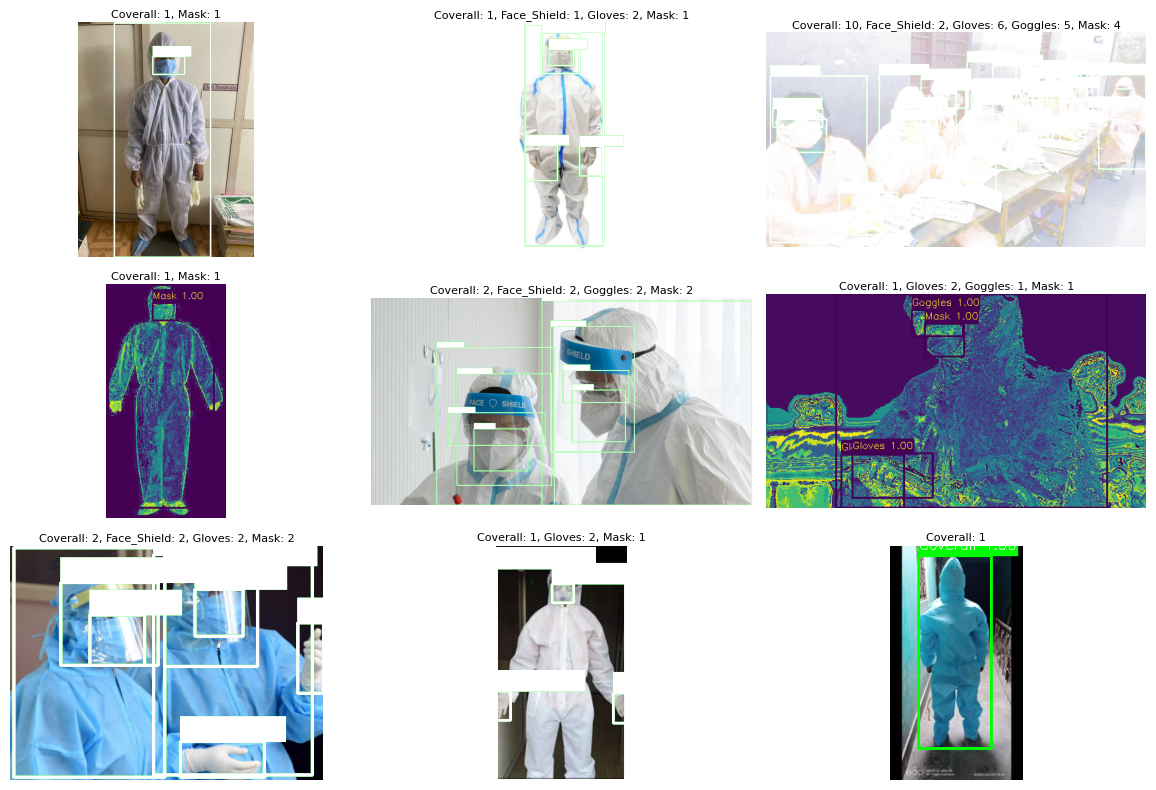

In [8]:
from dataeval_plots import plot

# Show a sample of outlier images (first 9)
if outlier_indices:
    sample = outlier_indices[:9]
    print("Outlier sample — flagged metrics per image:")
    for idx in sample:
        print(f"  Image {idx:>5d}: {', '.join(outlier_grouped[idx])}")
    _ = plot(ds, indices=sample, images_per_row=3, figsize=(12, 8), show_labels=True)

In [9]:
exact_groups = raw.duplicates["items"].get("exact", [])
near_groups = raw.duplicates["items"].get("near", [])

print(f"Exact duplicate groups: {len(exact_groups)}")
print(f"Near  duplicate groups: {len(near_groups)}")

Exact duplicate groups: 1
Near  duplicate groups: 12



Exact group 0: indices [133, 487]


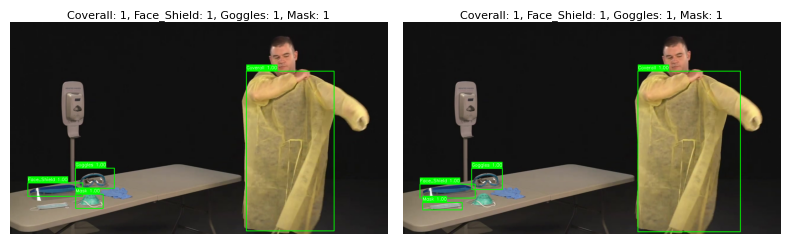

In [10]:
# Plot exact duplicate groups (if any)
for i, group in enumerate(exact_groups[:3]):
    indices = group if isinstance(group, list) else group["indices"]
    print(f"\nExact group {i}: indices {indices}")
    _ = plot(ds, indices=indices, images_per_row=len(indices), figsize=(4 * len(indices), 4), show_labels=True)


Near group 0: indices [37, 158]  (methods: ['phash'])

Near group 1: indices [59, 81, 176]  (methods: ['phash'])



Near group 2: indices [72, 101]  (methods: ['phash'])


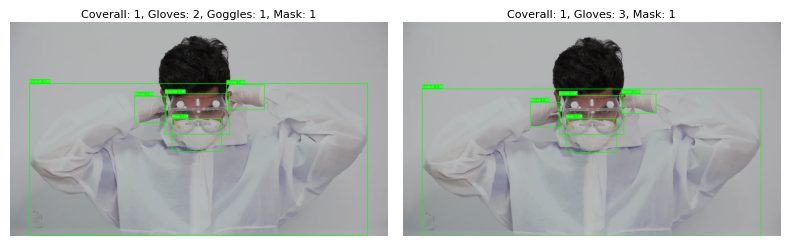

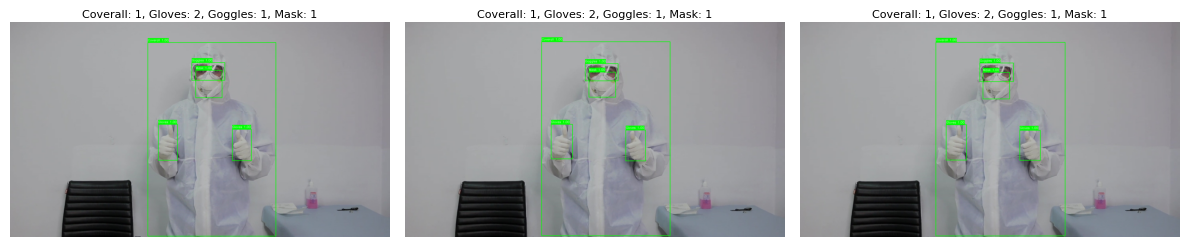

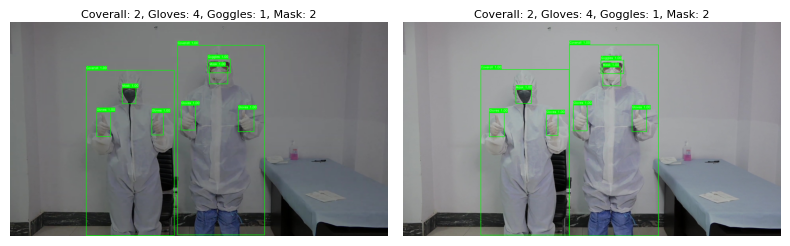

In [11]:
# Plot near duplicate groups (if any)
for i, group in enumerate(near_groups[:3]):
    indices = group["indices"]
    methods = group.get("methods", [])
    print(f"\nNear group {i}: indices {indices}  (methods: {methods})")
    _ = plot(ds, indices=indices, images_per_row=len(indices), figsize=(4 * len(indices), 4), show_labels=True)

In [12]:
# Define a preparatory pipeline — same params but mode="preparatory"
# Copy the advisory workflow and change name + mode
prep_workflow = advisory_workflow.model_copy(
    update={"name": "cppe5_prep_clean", "mode": "preparatory"},
)

task_prep = DataCleaningTaskConfig(
    name="cppe5-clean-prep",
    workflow="cppe5_prep_clean",
    sources="cppe5_src",
    extractor="bovw_ext",
)

config_prep = PipelineConfig(
    datasets=config.datasets,
    selections=config.selections,
    sources=config.sources,
    extractors=config.extractors,
    workflows=[advisory_workflow, prep_workflow],
    tasks=[task_prep],
)

result_prep = run_task(task_prep, config_prep, cache_dir=Path("./cache"))

In [13]:
if not result_prep.success:
    print(f"Workflow failed: {result_prep.errors}")
assert result_prep.success

In [14]:
meta = result_prep.metadata
print(f"Mode: {meta.mode}")
print(f"Flagged for removal : {meta.removed_count}")
print(f"Retained (clean)    : {len(meta.clean_indices)}")

if meta.flagged_indices:
    print(f"\nFirst 20 flagged indices: {meta.flagged_indices[:20]}")

Mode: preparatory
Flagged for removal : 74
Retained (clean)    : 426

First 20 flagged indices: [16, 24, 28, 31, 35, 50, 52, 60, 62, 66, 81, 95, 101, 103, 108, 110, 114, 127, 144, 158]


In [15]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 89689 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-06-09T17:45:18.028690Z",
    "dataset_id": "cppe5_train",
    "label_source": "huggingface",
    "model_id": "bovw_ext (bovw)",
    "preprocessor_id": null,
    "selection_id": "first500",
    "source_descriptions": [
      "cppe5_src (cppe5_train[first500])"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "cppe5_src",
          "dataset": "cppe5_train",
          "dataset_config": {
            "format
...
